In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import lime
import lime.lime_tabular
import dice_ml
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

DATA_PROCESSED = Path("../data/processed")
MODELS = Path("../src/models")
FIGURES = Path("../reports/figures")

# Load model and test data
xgb_model = joblib.load(MODELS / "xgboost_baseline.pkl")
X_test = pd.read_parquet(MODELS / "X_test.parquet")
df = pd.read_parquet(DATA_PROCESSED / "master_dataset.parquet")

FEATURES = [
    "forecast", "u10", "t2m", "ssrd",
    "hour", "day_of_week", "month",
    "is_weekend", "season",
    "actual_lag1", "actual_lag2", "actual_lag24",
    "rolling_mean_24h"
]
TARGET = "actual"

X_test.columns = FEATURES
X_train = df[FEATURES].iloc[:33433]
y_train = df[TARGET].iloc[:33433]

print("Setup complete")
print("X_test shape:", X_test.shape)

Setup complete
X_test shape: (7165, 13)


In [2]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=FEATURES,
    mode="regression",
    random_state=42
)
print("LIME explainer created")

LIME explainer created


Explaining prediction #5883
Predicted carbon intensity: 312.62 gCO2/kWh


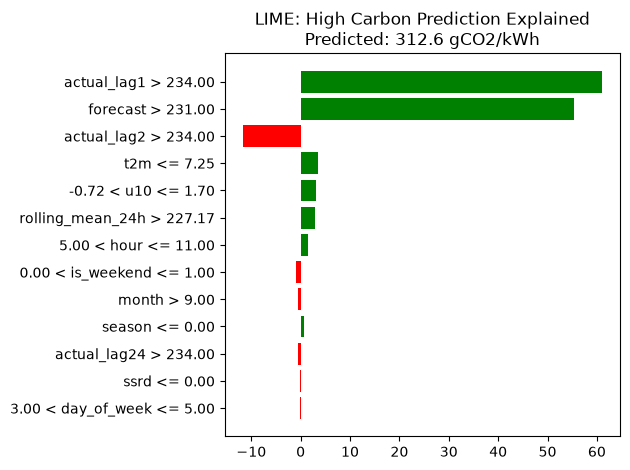

LIME high carbon plot saved


In [3]:
# Find a high carbon intensity prediction
y_pred = xgb_model.predict(X_test)
high_idx = np.argmax(y_pred)

print(f"Explaining prediction #{high_idx}")
print(f"Predicted carbon intensity: {y_pred[high_idx]:.2f} gCO2/kWh")

lime_exp_high = explainer_lime.explain_instance(
    data_row=X_test.iloc[high_idx].values,
    predict_fn=xgb_model.predict,
    num_features=13
)

fig = lime_exp_high.as_pyplot_figure()
plt.title(f"LIME: High Carbon Prediction Explained\n"
          f"Predicted: {y_pred[high_idx]:.1f} gCO2/kWh")
plt.tight_layout()
plt.savefig(FIGURES / "lime_high_carbon.png", dpi=150, bbox_inches="tight")
plt.show()
print("LIME high carbon plot saved")

Explaining prediction #6834
Predicted carbon intensity: 45.54 gCO2/kWh


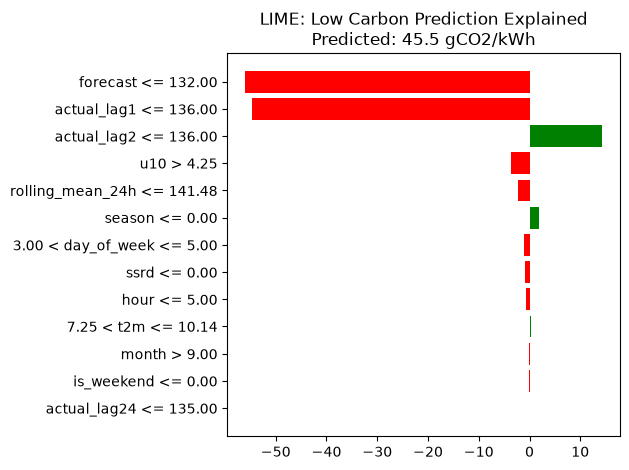

LIME low carbon plot saved


In [4]:
low_idx = np.argmin(y_pred)

print(f"Explaining prediction #{low_idx}")
print(f"Predicted carbon intensity: {y_pred[low_idx]:.2f} gCO2/kWh")

lime_exp_low = explainer_lime.explain_instance(
    data_row=X_test.iloc[low_idx].values,
    predict_fn=xgb_model.predict,
    num_features=13
)

fig = lime_exp_low.as_pyplot_figure()
plt.title(f"LIME: Low Carbon Prediction Explained\n"
          f"Predicted: {y_pred[low_idx]:.1f} gCO2/kWh")
plt.tight_layout()
plt.savefig(FIGURES / "lime_low_carbon.png", dpi=150, bbox_inches="tight")
plt.show()
print("LIME low carbon plot saved")

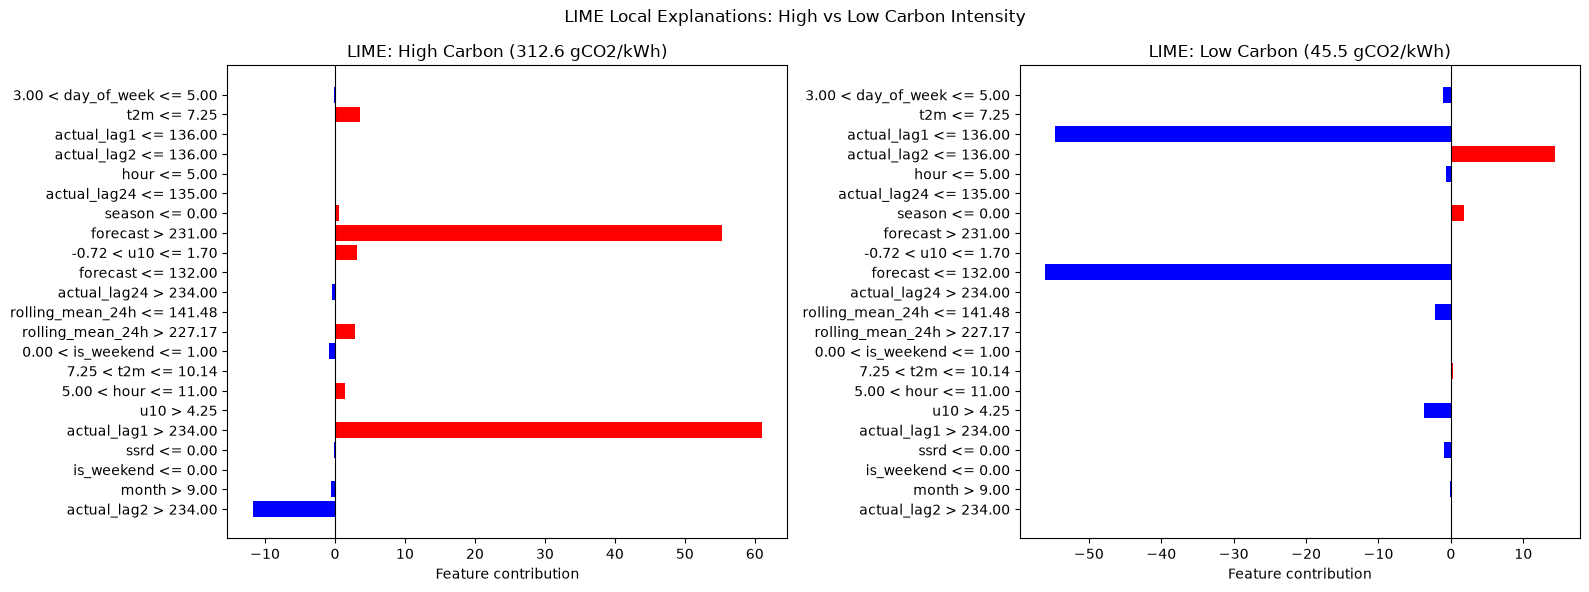

LIME comparison plot saved


In [5]:
high_exp = dict(lime_exp_high.as_list())
low_exp = dict(lime_exp_low.as_list())

all_features = list(set(list(high_exp.keys()) + list(low_exp.keys())))
high_vals = [high_exp.get(f, 0) for f in all_features]
low_vals = [low_exp.get(f, 0) for f in all_features]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_high = ["red" if v > 0 else "blue" for v in high_vals]
axes[0].barh(all_features, high_vals, color=colors_high)
axes[0].set_title(f"LIME: High Carbon ({y_pred[high_idx]:.1f} gCO2/kWh)")
axes[0].set_xlabel("Feature contribution")
axes[0].axvline(x=0, color="black", linewidth=0.8)

colors_low = ["red" if v > 0 else "blue" for v in low_vals]
axes[1].barh(all_features, low_vals, color=colors_low)
axes[1].set_title(f"LIME: Low Carbon ({y_pred[low_idx]:.1f} gCO2/kWh)")
axes[1].set_xlabel("Feature contribution")
axes[1].axvline(x=0, color="black", linewidth=0.8)

plt.suptitle("LIME Local Explanations: High vs Low Carbon Intensity")
plt.tight_layout()
plt.savefig(FIGURES / "lime_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("LIME comparison plot saved")

In [6]:
# DiCE - "What would need to change to get a LOWER carbon prediction?"
# This is counterfactual explanation

X_train_dice = df[FEATURES].iloc[:33433].copy()
y_train_dice = df[TARGET].iloc[:33433].copy()

dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train_dice, y_train_dice], axis=1),
    continuous_features=FEATURES,
    outcome_name=TARGET
)

dice_model = dice_ml.Model(model=xgb_model, backend="sklearn")

exp_dice = dice_ml.Dice(dice_data, dice_model, method="random")
print("DiCE explainer created")

DiCE explainer created


In [10]:
X_train_dice = df[FEATURES].iloc[:33433].copy()
y_train_dice = df[TARGET].iloc[:33433].copy()

dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train_dice, y_train_dice], axis=1),
    continuous_features=FEATURES,
    outcome_name=TARGET
)

dice_model = dice_ml.Model(
    model=xgb_model, 
    backend="sklearn",
    model_type="regressor"
)

exp_dice = dice_ml.Dice(dice_data, dice_model, method="random")
print("DiCE explainer created")

DiCE explainer created


In [12]:
query_instance = X_test.iloc[[high_idx]].copy()
print(f"Original prediction: {y_pred[high_idx]:.2f} gCO2/kWh")

# Use closer target range and genetic method
exp_dice_genetic = dice_ml.Dice(dice_data, dice_model, method="genetic")

cf = exp_dice_genetic.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_range=[150, 220],
    features_to_vary=[
        "actual_lag1", "actual_lag2", "actual_lag24",
        "rolling_mean_24h", "u10", "t2m", "ssrd"
    ]
)

cf.visualize_as_dataframe(show_only_changes=True)

Original prediction: 312.62 gCO2/kWh


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 12.90it/s]

Query instance (original outcome : 312.6158447265625)


,forecast,u10,t2m,ssrd,hour,day_of_week,month,is_weekend,season,actual_lag1,actual_lag2,actual_lag24,rolling_mean_24h,actual
0,312,-0.105206,2.732483,0.0,6,5,12,1,0,309.0,306.0,292.0,288.604156,312.615845



Diverse Counterfactual set (new outcome: [150, 220])


,forecast,u10,t2m,ssrd,hour,day_of_week,month,is_weekend,season,actual_lag1,actual_lag2,actual_lag24,rolling_mean_24h,actual
0,-,-2.058783531188965,0.7785645127296448,-,-,-,-,-,-,38.0,238.0,247.0,58.39583,212.5762939453125
0,-,-2.058783531188965,6.149200439453125,-,-,-,-,-,-,38.0,244.0,-,58.39583,211.55130004882812
0,-,-2.988328456878662,0.7785645127296448,-,-,-,-,-,-,38.0,247.0,38.0,58.39583,211.22804260253906


Counterfactuals shape: (3, 14)
Features that changed: ['u10', 't2m', 'actual_lag1', 'actual_lag2', 'actual_lag24', 'rolling_mean_24h']


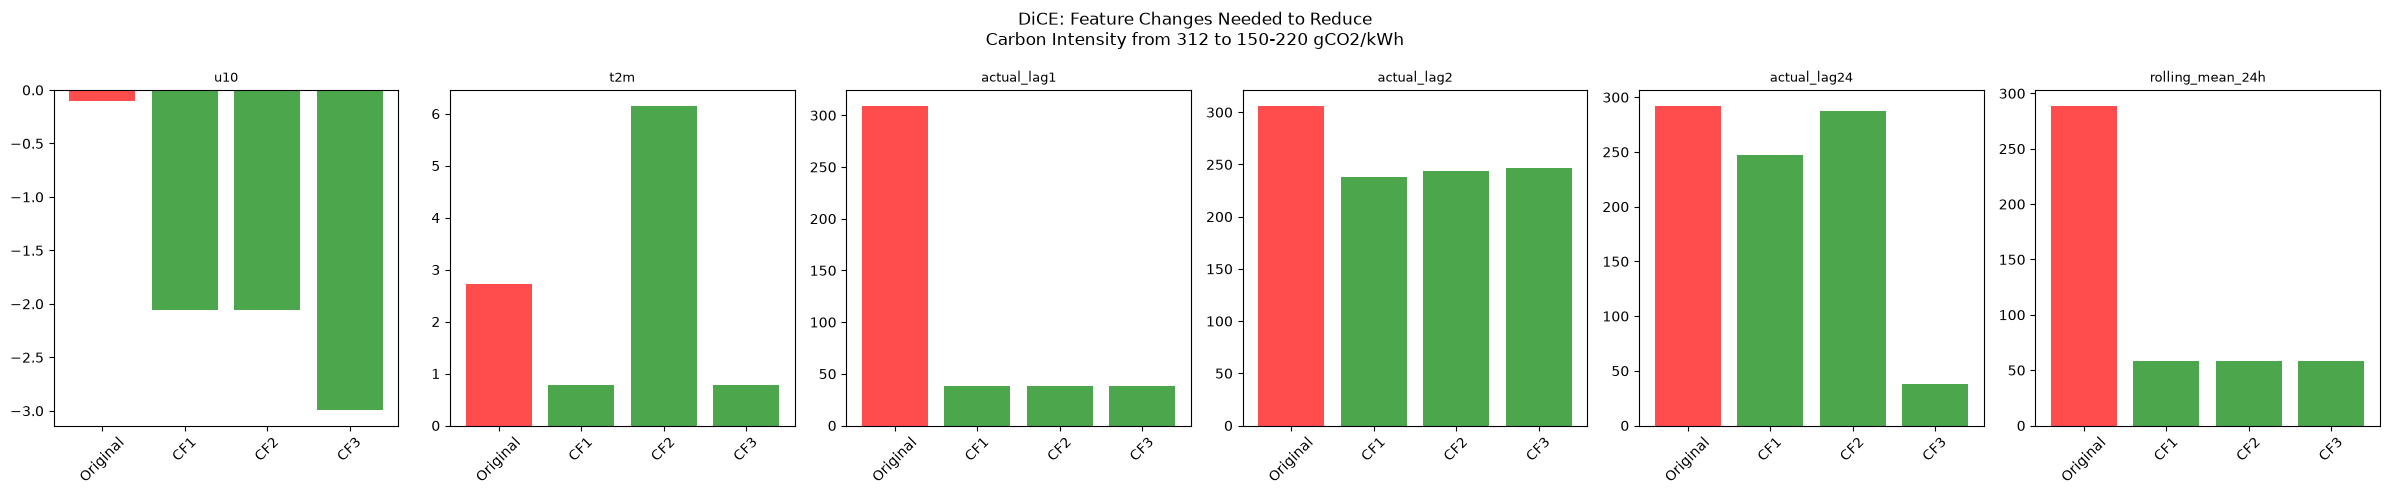

DiCE plot saved


In [13]:
cf_df = cf.cf_examples_list[0].final_cfs_df
print("Counterfactuals shape:", cf_df.shape)

# Plot which features changed
changed_features = []
original_vals = query_instance.iloc[0]

for col in FEATURES:
    if col in cf_df.columns:
        if not (cf_df[col] == original_vals[col]).all():
            changed_features.append(col)

print("Features that changed:", changed_features)

fig, axes = plt.subplots(1, len(changed_features), 
                          figsize=(4*len(changed_features), 5))
if len(changed_features) == 1:
    axes = [axes]

for i, feat in enumerate(changed_features):
    original = original_vals[feat]
    cf_vals = cf_df[feat].values
    
    all_vals = [original] + list(cf_vals)
    labels = ["Original"] + [f"CF{j+1}" for j in range(len(cf_vals))]
    colors = ["red"] + ["green"]*len(cf_vals)
    
    axes[i].bar(labels, all_vals, color=colors, alpha=0.7)
    axes[i].set_title(feat, fontsize=9)
    axes[i].tick_params(axis="x", rotation=45)

plt.suptitle("DiCE: Feature Changes Needed to Reduce\nCarbon Intensity from 312 to 150-220 gCO2/kWh")
plt.tight_layout()
plt.savefig(FIGURES / "dice_counterfactuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("DiCE plot saved")